# Bayesian Active Learning

In [2]:
import os
os.chdir('/Users/madsbirch/Documents/4_semester/BAL/bayesian-active-learning')
print("Current working directory: {0}".format(os.getcwd()))

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload
%autoreload 2

Current working directory: /Users/madsbirch/Documents/4_semester/BAL/bayesian-active-learning
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons, make_circles, make_classification
from matplotlib.colors import ListedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable

import pickle

import torch
import torchvision
import torchvision.transforms as transforms

import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, SubsetRandomSampler


from src.models.model import MLP, CNN
from src.data.data import get_dataloaders, TwoMoons
from src.models.train_model import train, test
from src.features.utils import random_query, query_the_oracle, plot_decision_bound, get_softmax_grid, get_entropy_grid

torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

# Set device
device = "mps" if torch.backends.mps.is_available() else "cpu"
device = 'cpu'
print(f"Using device: {device}")

FIGURE_PATH = '/Users/madsbirch/Documents/4_semester/BAL/Bayesian-Active-Learning/reports/figures/'

Using device: cpu


Epoch:   0 | Train Loss: 0.69 | Train Acc: 51.0%
Epoch:   1 | Train Loss: 0.69 | Train Acc: 54.8%
Epoch:   2 | Train Loss: 0.68 | Train Acc: 58.5%
Epoch:   3 | Train Loss: 0.67 | Train Acc: 63.6%
Epoch:   4 | Train Loss: 0.66 | Train Acc: 66.5%
Epoch:   5 | Train Loss: 0.66 | Train Acc: 71.8%
Epoch:   6 | Train Loss: 0.65 | Train Acc: 72.6%
Epoch:   7 | Train Loss: 0.65 | Train Acc: 75.9%
Epoch:   8 | Train Loss: 0.64 | Train Acc: 77.9%
Epoch:   9 | Train Loss: 0.62 | Train Acc: 78.0%
Epoch:  10 | Train Loss: 0.62 | Train Acc: 76.9%
Epoch:  11 | Train Loss: 0.61 | Train Acc: 81.4%
Epoch:  12 | Train Loss: 0.60 | Train Acc: 78.9%
Epoch:  13 | Train Loss: 0.59 | Train Acc: 81.5%
Epoch:  14 | Train Loss: 0.58 | Train Acc: 81.6%
Epoch:  15 | Train Loss: 0.58 | Train Acc: 80.2%
Epoch:  16 | Train Loss: 0.57 | Train Acc: 81.5%
Epoch:  17 | Train Loss: 0.57 | Train Acc: 82.6%
Epoch:  18 | Train Loss: 0.56 | Train Acc: 81.9%
Epoch:  19 | Train Loss: 0.55 | Train Acc: 81.4%
Epoch:  20 | Train L

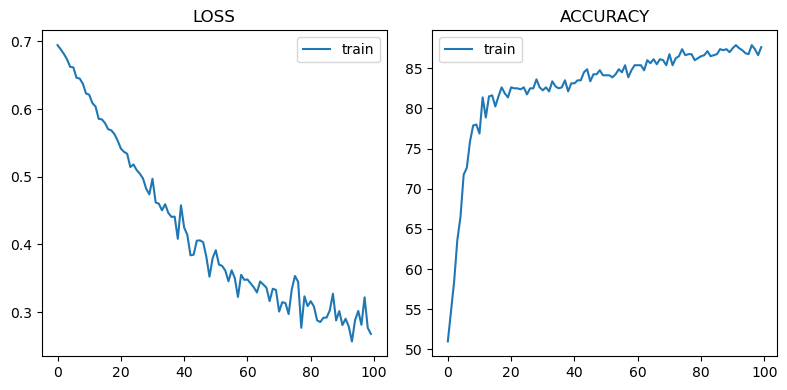

Accuracy on the test set: 86.0 %


In [4]:
import torch.optim as optim

moons = make_moons(n_samples=1000, noise = 0.2)
trainloader, testloader = get_dataloaders(moons, batch_size = 256, val_split = 0.2, return_idx = True)

lr = 1e-4
model = MLP(drop_out=0.2)
optimizer = optim.Adam(model.parameters(), lr = lr)

train(model, trainloader, optimizer, device, num_epochs=100, plot = True)

acc = test(model, testloader, device, display = True)

In [8]:
moons = make_moons(n_samples=1000, noise = 0.2)
trainloader, testloader = get_dataloaders(moons, 256, 0.2)
train_set = TwoMoons(moons_data=moons)

model = MLP()
optimizer = optim.Adam(model.parameters(), lr = 1e-5)
batch_size = 1
num_queries = 50
query_size = 2


TEST_ACC = []
labeled_idx_list = []

for query in range(num_queries):
    # quering data points
    sample_idx = query_the_oracle(model, train_set, device, query_strategy='random', query_size=query_size)
    labeled_idx = np.where(train_set.unlabeled_mask == 0)[0]
    train_set.update_mask(sample_idx)
    labeled_idx_list.extend(sample_idx)

    labeled_loader = DataLoader(train_set, batch_size=batch_size, num_workers=0,
                                sampler=SubsetRandomSampler(labeled_idx))

    # train model
    train(model, labeled_loader, optimizer, device, num_epochs=30, plot = False, printout = False)

    # test model
    test_acc = test(model, device, testloader, display = False)
    TEST_ACC.append(test_acc)

    print(f'# Samples: {query*query_size:3d} | Test accururacy : {test_acc:.2f}%')
    
    #if query%5 == 0:
     #   plot_decision_bound(model)

plt.plot(TEST_ACC)
plt.show()

TypeError: '<' not supported between instances of 'type' and 'int'

In [5]:
# generate data
moons_data = make_moons(n_samples = 1000, noise = 0.2, random_state=9)

# dataloader and dataset class
_, testloader = get_dataloaders(moons_data = moons_data, val_split = 0.2, batch_size=256)
train_set = TwoMoons(moons_data = moons_data)

# model, optimizer nad hyper parameters'
drop_out = 0.5
model = MLP(drop_out=drop_out)

num_epochs = 100
batch_size = 256

# list of sampling strategies
strat_list = ['bald', 'entropy', 'margin', 'random']

init_pool_size = 10
init_pool_idx = np.random.randint(0,1000, size = init_pool_size).tolist()

STRATEGY: bald
ITER:  1
# Samples:   0 | Test accururacy : 78.00%
# Samples:   3 | Test accururacy : 83.00%
# Samples:   6 | Test accururacy : 87.00%
# Samples:   9 | Test accururacy : 88.00%
# Samples:  12 | Test accururacy : 90.00%
# Samples:  15 | Test accururacy : 90.50%
# Samples:  18 | Test accururacy : 92.00%
# Samples:  21 | Test accururacy : 92.50%
# Samples:  24 | Test accururacy : 92.50%
# Samples:  27 | Test accururacy : 92.50%
# Samples:  30 | Test accururacy : 92.50%
# Samples:  33 | Test accururacy : 93.00%
# Samples:  36 | Test accururacy : 93.50%
# Samples:  39 | Test accururacy : 95.00%
# Samples:  42 | Test accururacy : 95.00%
# Samples:  45 | Test accururacy : 95.00%
# Samples:  48 | Test accururacy : 95.00%
# Samples:  51 | Test accururacy : 95.50%
# Samples:  54 | Test accururacy : 95.50%
# Samples:  57 | Test accururacy : 95.50%
# Samples:  60 | Test accururacy : 95.50%
# Samples:  63 | Test accururacy : 96.50%
# Samples:  66 | Test accururacy : 97.00%
# Samples:

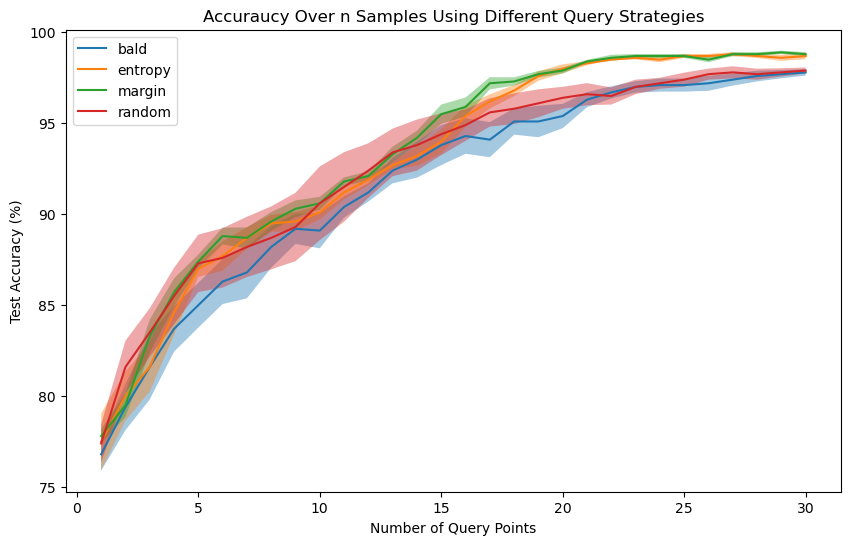

In [17]:
num_queries = 30
query_size = 3
lr = 1e-4

query_dict = {
    'bald': {'acc_mean': [], 'acc_se': []},
    'random': {'acc_mean': [], 'acc_se': []},
    'entropy': {'acc_mean': [], 'acc_se': []},
    'margin': {'acc_mean': [], 'acc_se': []}
}

## setup ##
save_dict = False
plot = True

n_iter = 5
TEST_ACC = np.zeros((n_iter, num_queries))

for s in strat_list:
    print(f'STRATEGY: {s}')
    for i in range(n_iter):
        print(f'ITER: {i+1:2d}')
        
        # reset dataset, model and optimizer
        train_set.reset_mask()
        model = MLP(drop_out=drop_out)
        optimizer = optim.Adam(model.parameters(), lr = lr)
        
        # train on initial pool
        train_set.update_mask(init_pool_idx)
        labeled_loader = DataLoader(train_set, batch_size=batch_size, num_workers=0,
                                        sampler=SubsetRandomSampler(init_pool_idx), shuffle = False)
    
        model = train(model, labeled_loader, optimizer, device, num_epochs=200, plot = False, printout = False)
    
        for query in range(num_queries):
            # quering data points
            sample_idx = query_the_oracle(model, train_set, device, query_strategy=s, query_size=query_size, T = 100, batch_size=batch_size)
            train_set.update_mask(sample_idx)
            labeled_idx = np.where(train_set.unlabeled_mask == 0)[0]
            labeled_loader = DataLoader(train_set, batch_size=batch_size, num_workers=0,
                                        sampler=SubsetRandomSampler(labeled_idx), shuffle=False)

            # train model
            model = train(model,labeled_loader,optimizer, device, num_epochs=num_epochs, plot = False, printout = False)

            # test model
            test_acc = test(model, testloader, device, display = False)
            TEST_ACC[i,query] = test_acc

            print(f'# Samples: {query*query_size:3d} | Test accururacy : {test_acc:.2f}%')

    query_dict[s]['acc_se'] = TEST_ACC.std(0)/np.sqrt(n_iter)
    query_dict[s]['acc_mean']  = TEST_ACC.mean(0)
    
if save_dict:
    with open("QUERY_DICT_50", "wb") as fp:
        pickle.dump(query_dict, fp)

if plot:
    x = np.linspace(1,num_queries,num_queries)
    plt.figure(figsize=(10,6))

    for s in strat_list:
        mean = query_dict[s]['acc_mean']
        std = query_dict[s]['acc_se']
        plt.plot(x, mean, label = s)
        plt.legend()
        plt.title('Accuraucy Over n Samples Using Different Query Strategies')
        plt.xlabel('Number of Query Points')
        plt.ylabel('Test Accuracy (%)')
        plt.fill_between(x, mean+std, mean-std, alpha = 0.4)
    plt.savefig('reports/figures/TwoMoons_results_4.png')
    plt.show()

### Plot in 2D

calculating: bald
calculating: entropy
calculating: margin
calculating: random


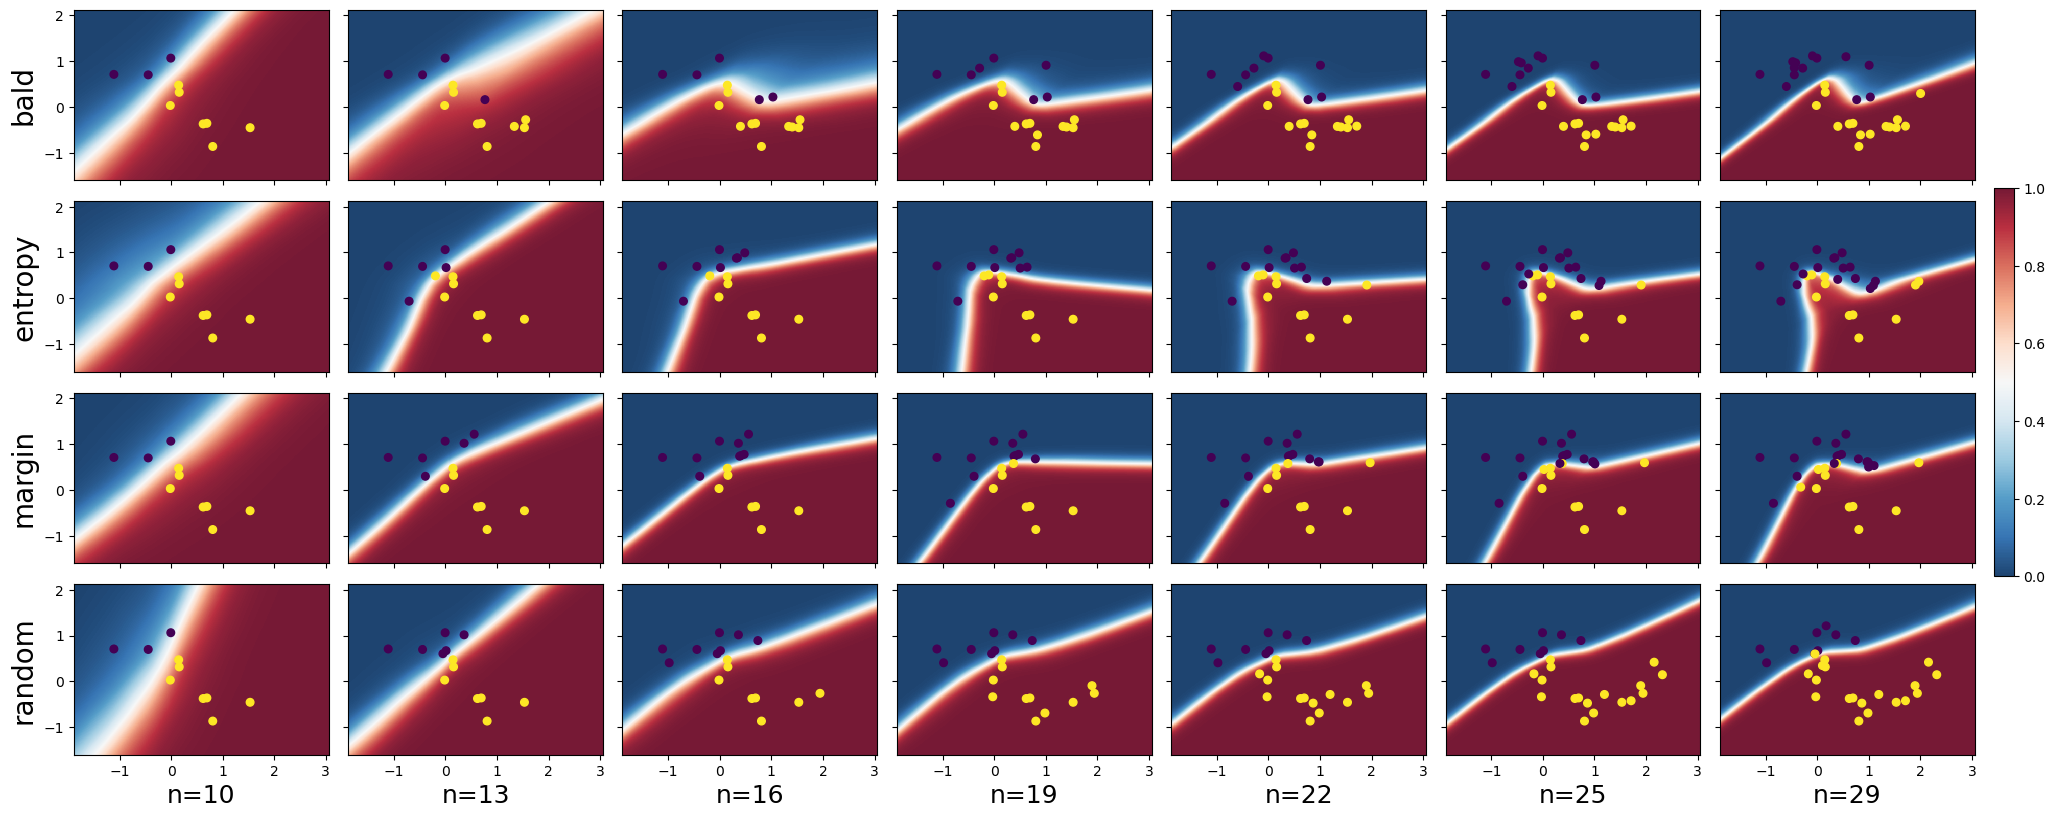

In [19]:
lr = 6e-4
num_queries = 6
query_size = 3

# figure init
fig, axs = plt.subplots(nrows=len(strat_list), ncols=num_queries+1, figsize=(20, 8),sharex=True, sharey=True)


for i, strat in enumerate(strat_list):
    print(f'calculating: {strat}')
    j = 0
    
    # reset dataset, model and optimizer
    train_set.reset_mask()
    model = MLP(drop_out=drop_out)
    optimizer = optim.Adam(model.parameters(), lr = lr)
    
    # train on initial pool
    train_set.update_mask(init_pool_idx)
    labeled_loader = DataLoader(train_set, batch_size=batch_size, num_workers=0,
                                        sampler=SubsetRandomSampler(init_pool_idx), shuffle = False)
    
    model = train(model, labeled_loader, optimizer, device, num_epochs=num_epochs, plot = False, printout = False)
    
    # plot initial 10 data points, first col in plot
    X, y, xx, yy, softmax_out = get_softmax_grid(model, moons_data = moons_data)

    mesh = axs[i,j].pcolormesh(xx, yy, softmax_out, cmap=plt.cm.RdBu_r, alpha = 0.9)
    axs[i,0].scatter(X[init_pool_idx,0], X[init_pool_idx,1], c = y[init_pool_idx], s = 30)
    axs[i,0].set_xlim(X[:,0].min()-0.5, X[:,0].max()+0.5)
    axs[i,0].set_ylim(X[:,1].min()-0.5, X[:,1].max()+0.5)
    
    labeled_idx_list = []
    
    for query in range(num_queries):
        # quering data points
        
        sample_idx = query_the_oracle(model, train_set, device, query_strategy=strat, query_size=query_size, batch_size=batch_size)
        train_set.update_mask(sample_idx)
        labeled_idx = np.where(train_set.unlabeled_mask == 0)[0]
        labeled_idx_list.extend(sample_idx)
        
        # define a list for plotting the initial 10 points + the queried points
        plot_idx = init_pool_idx + labeled_idx_list      
                
        labeled_loader = DataLoader(train_set, batch_size=batch_size, num_workers=0,
                                        sampler=SubsetRandomSampler(labeled_idx), shuffle = False)

        # train model
        model = train(model, labeled_loader, optimizer, device, num_epochs=num_epochs, plot = False, printout = False)
        
        # plot grid and scatter for the rest of the cols.
        X, y, xx, yy, softmax_out = get_softmax_grid(model, moons_data = moons_data)

        mesh = axs[i,j+1].pcolormesh(xx, yy, softmax_out, cmap=plt.cm.RdBu_r, alpha = 0.9)
        axs[i,j+1].scatter(X[plot_idx,0], X[plot_idx,1], c = y[plot_idx], s = 30)
        axs[i,j+1].set_xlim(X[:,0].min()-0.5, X[:,0].max()+0.5)
        axs[i,j+1].set_ylim(X[:,1].min()-0.5, X[:,1].max()+0.5)
        
        j = j +1

fig.tight_layout()
fig.colorbar(mesh, ax=axs.ravel().tolist(), fraction=0.01, pad=0.01)

# set ylabels to strategy
for i, strat in enumerate(strat_list):
    axs[i,0].set_ylabel(strat, fontsize=20)
    #axs[i,0].set_ylim(X[:,1].min()-0.5, X[:,1].max()+0.5)

# set xlabels to number of sampled data points.
ns = np.linspace(0, query_size*num_queries+1, num_queries+1)

for i, n in enumerate(ns):
    axs[len(strat_list)-1,i].set_xlabel(f'n={int(10+n)}', fontsize=18)
    #axs[len(strat_list)-1,i].set_xlim(X[:,0].min()-0.5, X[:,0].max()+0.5)

plt.savefig(FIGURE_PATH+'dec_bound_8.png')
plt.show()

### Plotting acquisition function output

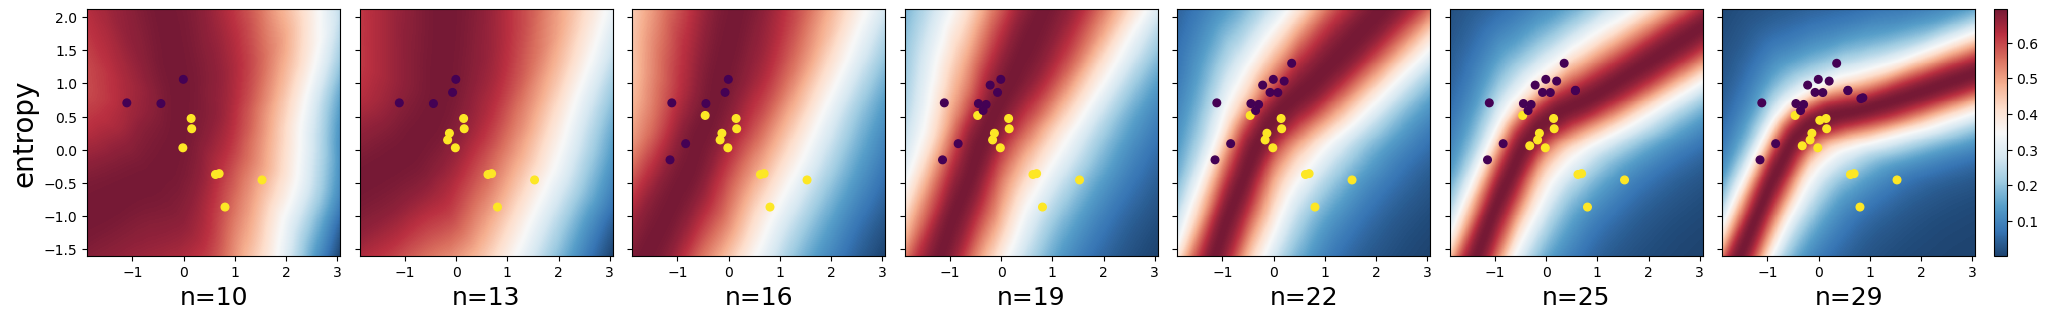

In [21]:
lr = 1e-4
num_queries = 6
query_size = 3

# figure init
fig, axs = plt.subplots(nrows=1, ncols=num_queries+1, figsize=(20, 3),sharex=True, sharey=True)
j = 0

# reset dataset, model and optimizer
train_set.reset_mask()
model = MLP(drop_out=drop_out)
optimizer = optim.Adam(model.parameters(), lr = lr)

# train on initial pool
train_set.update_mask(init_pool_idx)
labeled_loader = DataLoader(train_set, batch_size=batch_size, num_workers=0,
                                    sampler=SubsetRandomSampler(init_pool_idx), shuffle = False)

model = train(model, labeled_loader, optimizer, device, num_epochs=num_epochs, plot = False, printout = False)

# plot initial 10 data points, first col in plot
X, y, xx, yy, entropy_out = get_entropy_grid(model, moons_data = moons_data)

mesh = axs[0].pcolormesh(xx, yy, entropy_out, cmap=plt.cm.RdBu_r, alpha = 0.9)
axs[0].scatter(X[init_pool_idx,0], X[init_pool_idx,1], c = y[init_pool_idx], s = 30)
axs[0].set_xlim(X[:,0].min()-0.5, X[:,0].max()+0.5)
axs[0].set_ylim(X[:,1].min()-0.5, X[:,1].max()+0.5)

labeled_idx_list = []

for i, query in enumerate(range(num_queries)):
    # quering data points
    
    sample_idx = query_the_oracle(model, train_set, device, query_strategy='entropy', query_size=query_size)
    train_set.update_mask(sample_idx)
    labeled_idx = np.where(train_set.unlabeled_mask == 0)[0]
    labeled_idx_list.extend(sample_idx)
    
    # define a list for plotting the initial 10 points + the queried points
    plot_idx = init_pool_idx + labeled_idx_list      
            
    labeled_loader = DataLoader(train_set, batch_size=batch_size, num_workers=0,
                                    sampler=SubsetRandomSampler(labeled_idx), shuffle = False)

    # train model
    model = train(model, labeled_loader, optimizer, device, num_epochs=num_epochs, plot = False, printout = False)
    
    # plot grid and scatter for the rest of the cols.
    X, y, xx, yy, entropy_out = get_entropy_grid(model, moons_data = moons_data)

    mesh = axs[i+1].pcolormesh(xx, yy, entropy_out, cmap=plt.cm.RdBu_r, alpha = 0.9)
    axs[i+1].scatter(X[plot_idx,0], X[plot_idx,1], c = y[plot_idx], s = 30)
    axs[i+1].set_xlim(X[:,0].min()-0.5, X[:,0].max()+0.5)
    axs[i+1].set_ylim(X[:,1].min()-0.5, X[:,1].max()+0.5)


fig.tight_layout()
fig.colorbar(mesh, ax=axs.ravel().tolist(), fraction=0.01, pad=0.01)

# set ylabels to strategy
axs[0].set_ylabel('entropy', fontsize=20)

# set xlabels to number of sampled data points.
ns = np.linspace(0, query_size*num_queries+1, num_queries+1)

for i, n in enumerate(ns):
    axs[i].set_xlabel(f'n={int(10+n)}', fontsize=18)

plt.savefig(FIGURE_PATH+'dec_bound_10.png')
plt.show()

### BALD with Monte Carlo Dropout

Experiments:
- Different values of T for MC_dropout.
- Laplace Approx
- PLot BALD output


Questions:
- Dropout in which layers?
- Does the output of BALD look correct?

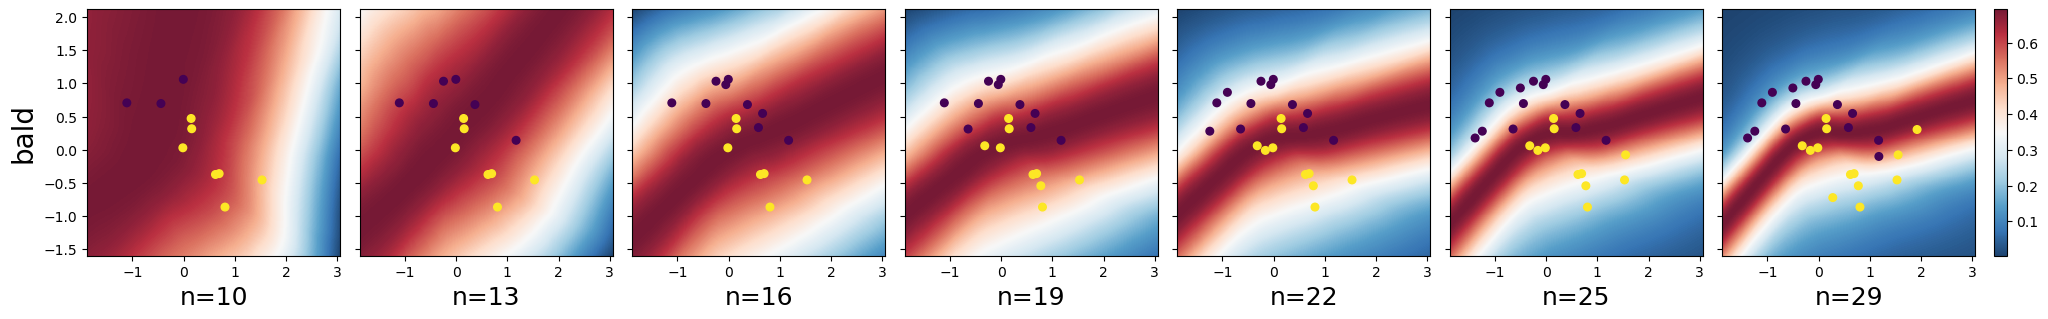

In [22]:
lr = 1e-4
num_queries = 6
query_size = 3

# figure init
fig, axs = plt.subplots(nrows=1, ncols=num_queries+1, figsize=(20, 3),sharex=True, sharey=True)
j = 0

# reset dataset, model and optimizer
train_set.reset_mask()
model = MLP(drop_out=drop_out)
optimizer = optim.Adam(model.parameters(), lr = lr)

# train on initial pool
train_set.update_mask(init_pool_idx)
labeled_loader = DataLoader(train_set, batch_size=batch_size, num_workers=0,
                                    sampler=SubsetRandomSampler(init_pool_idx), shuffle = False)

model = train(model, labeled_loader, optimizer, device, num_epochs=num_epochs, plot = False, printout = False)

# plot initial 10 data points, first col in plot
X, y, xx, yy, entropy_out = get_entropy_grid(model, moons_data = moons_data)

mesh = axs[0].pcolormesh(xx, yy, entropy_out, cmap=plt.cm.RdBu_r, alpha = 0.9)
axs[0].scatter(X[init_pool_idx,0], X[init_pool_idx,1], c = y[init_pool_idx], s = 30)
axs[0].set_xlim(X[:,0].min()-0.5, X[:,0].max()+0.5)
axs[0].set_ylim(X[:,1].min()-0.5, X[:,1].max()+0.5)

labeled_idx_list = []

for i, query in enumerate(range(num_queries)):
    # quering data points
    
    sample_idx = query_the_oracle(model, train_set, device, query_strategy='bald', query_size=query_size, T = 100)
    train_set.update_mask(sample_idx)
    labeled_idx = np.where(train_set.unlabeled_mask == 0)[0]
    labeled_idx_list.extend(sample_idx)
    
    # define a list for plotting the initial 10 points + the queried points
    plot_idx = init_pool_idx + labeled_idx_list      
            
    labeled_loader = DataLoader(train_set, batch_size=batch_size, num_workers=0,
                                    sampler=SubsetRandomSampler(labeled_idx), shuffle = False)

    # train model
    model = train(model, labeled_loader, optimizer, device, num_epochs=num_epochs, plot = False, printout = False)
    
    # plot grid and scatter for the rest of the cols.
    X, y, xx, yy, entropy_out = get_entropy_grid(model, moons_data = moons_data)

    mesh = axs[i+1].pcolormesh(xx, yy, entropy_out, cmap=plt.cm.RdBu_r, alpha = 0.9)
    axs[i+1].scatter(X[plot_idx,0], X[plot_idx,1], c = y[plot_idx], s = 30)
    axs[i+1].set_xlim(X[:,0].min()-0.5, X[:,0].max()+0.5)
    axs[i+1].set_ylim(X[:,1].min()-0.5, X[:,1].max()+0.5)


fig.tight_layout()
fig.colorbar(mesh, ax=axs.ravel().tolist(), fraction=0.01, pad=0.01)

# set ylabels to strategy
axs[0].set_ylabel('bald', fontsize=20)

# set xlabels to number of sampled data points.
ns = np.linspace(0, query_size*num_queries+1, num_queries+1)

for i, n in enumerate(ns):
    axs[i].set_xlabel(f'n={int(10+n)}', fontsize=18)

plt.savefig(FIGURE_PATH+'dec_bound_10.png')
plt.show()

In [17]:
from laplace import Laplace

train_loader, test_loader = get_dataloaders(moons_data = moons_data, val_split = 0.2, batch_size=256, return_idx=False)


# Pre-trained model
model = MLP(drop_out=0.50)  

# User-specified LA flavor
la = Laplace(model, 'classification',
             subset_of_weights='all',
             hessian_structure='full')
la.fit(train_loader)

/Users/madsbirch/Documents/4_semester/BAL/bayesian-active-learning/env/lib/python3.8/site-packages/backpack/extensions/backprop_extension.py:106: UserWarning: Extension saving to grad_batch does not have an extension for Module <class 'src.models.model.MLP'> although the module has parameters
  warnings.warn(


In [18]:
la.optimize_prior_precision(method='CV', val_loader=test_loader)

In [19]:
la_samples = la.sample(n_samples = 1000)

In [20]:
la_samples.shape

torch.Size([1000, 10602])

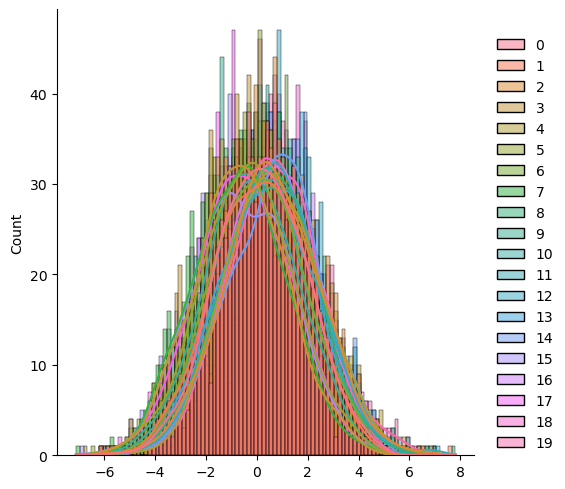

In [21]:
post_weights = la.sample(1000).detach().cpu().numpy()
sns.displot(post_weights[:,:20], bins = 100, kde = True)
plt.show()